# Network Analysis and Stock Price Comparison

This notebook builds the network analysis and the stock price comparison for the NVIDIA tweets project.

We build three co-occurrence networks (hashtags, mentions, cashtags) and one directed user → mentioned-account network, compute centrality measures, detect communities, and then compare the daily sentiment signal from Notebook 2 against NVIDIA's daily stock price.

The processed inputs are produced by `02_text_cleaning_and_sentiment.ipynb`:
- `../data/processed/nvidia_tweets_sentiment_processed.csv` — tweets with `hashtags`, `mentions`, `cashtags`, `sentiment`, and `compound_score`.
- `../data/processed/nvidia_daily_sentiment.csv` — daily tweet volume and average sentiment.


## 1. Import Libraries

We import pandas/numpy for data handling, NetworkX for the graph analysis, matplotlib for plotting, yfinance for the NVIDIA stock price, and `ast.literal_eval` for parsing the list-typed CSV columns back from text.

In [1]:
import os
import ast
from collections import Counter
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import yfinance as yf

## 2. Load the Processed Tweet Data

We load the per-tweet processed dataset from Notebook 2. The `hashtags`, `mentions`, and `cashtags` columns are stored as text (`"['$NVDA', '$TSLA']"`) when they are written to CSV, so we use `ast.literal_eval` to turn them back into Python lists.

In [2]:
tweet_path = "../data/processed/nvidia_tweets_sentiment_processed.csv"

df = pd.read_csv(tweet_path)

# Convert datetime and date columns
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date

# Parse the list-typed columns back from their string representation
def safe_parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

for col in ["hashtags", "mentions", "cashtags"]:
    df[col] = df[col].apply(safe_parse_list)

# Normalise the tokens
df["hashtags"] = df["hashtags"].apply(lambda lst: [t.lower() for t in lst])
df["mentions"] = df["mentions"].apply(lambda lst: [t.lower() for t in lst])
df["cashtags"] = df["cashtags"].apply(lambda lst: [t.upper() for t in lst])

print("Processed tweets shape:", df.shape)
df[["Datetime", "Username", "hashtags", "mentions", "cashtags", "sentiment"]].head()

Processed tweets shape: (99633, 13)


,Datetime,Username,hashtags,mentions,cashtags,sentiment
0,2023-02-06 10:07:17+00:00,RyderJohnston6,[],[],[$NVDA],positive
1,2023-02-06 10:06:30+00:00,k_mebane,[],[],[$NVDA],positive
2,2023-02-06 10:06:08+00:00,RonaldBevan2,[],[],[$NVDA],positive
3,2023-02-06 10:05:43+00:00,Eva077777,[],[],[$NVDA],positive
4,2023-02-06 10:03:49+00:00,MrBlackTrading,[],[],"[$RSLS, $EDSA, $KODK, $DOW, $GNUS, $IDEX, $BSB...",neutral


## 3. Output Folders

We make sure the `figures` and `tables` output folders exist so that all generated artefacts can be saved.

In [3]:
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

## 4. Helper Functions

The three co-occurrence networks are built with the same logic, so we wrap the work into helpers:
- `build_cooccurrence_graph` builds an undirected weighted graph from a column of token lists. An edge between two tokens has a weight equal to the number of tweets they both appear in.
- `top_centrality_table` computes degree / weighted-degree / betweenness / eigenvector centrality and returns a sorted dataframe.
- `draw_network` plots the network using community colours and node sizes proportional to weighted degree.

In [4]:
def build_cooccurrence_graph(token_lists, top_n=50, min_pair_weight=2):
    """Build a weighted undirected co-occurrence graph from a series of token lists.

    Parameters
    ----------
    token_lists : iterable of list[str]
        Each item is the list of tokens that appeared in a single tweet.
    top_n : int
        Only keep the top_n most frequent tokens as nodes (to keep the graph readable).
    min_pair_weight : int
        Drop edges whose co-occurrence count is below this threshold.
    """
    # Count token frequencies and pick the top_n
    token_counter = Counter()
    for tokens in token_lists:
        token_counter.update(set(tokens))  # set(): one tweet = one occurrence
    top_tokens = {tok for tok, _ in token_counter.most_common(top_n)}

    # Count co-occurrences over the top_n vocabulary
    pair_counter = Counter()
    for tokens in token_lists:
        unique_tokens = set(tokens) & top_tokens
        if len(unique_tokens) >= 2:
            for a, b in combinations(sorted(unique_tokens), 2):
                pair_counter[(a, b)] += 1

    G = nx.Graph()
    # Add nodes with their tweet frequency as an attribute
    for tok in top_tokens:
        G.add_node(tok, frequency=int(token_counter[tok]))
    # Add edges that meet the minimum weight threshold
    for (a, b), w in pair_counter.items():
        if w >= min_pair_weight:
            G.add_edge(a, b, weight=int(w))
    return G


def top_centrality_table(G, top_k=15):
    """Compute several centrality measures and return them as a dataframe."""
    if G.number_of_nodes() == 0:
        return pd.DataFrame()

    degree = dict(G.degree())
    weighted_degree = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)
    try:
        eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        # Fall back if eigenvector fails (e.g., disconnected graph)
        eigenvector = {n: np.nan for n in G.nodes()}

    table = pd.DataFrame({
        "node": list(G.nodes()),
        "degree": [degree[n] for n in G.nodes()],
        "weighted_degree": [weighted_degree[n] for n in G.nodes()],
        "betweenness": [betweenness[n] for n in G.nodes()],
        "eigenvector": [eigenvector[n] for n in G.nodes()],
    })
    table = table.sort_values("weighted_degree", ascending=False).reset_index(drop=True)
    return table.head(top_k)


def detect_communities(G):
    """Greedy modularity communities; returns a node->community-id mapping."""
    if G.number_of_edges() == 0:
        return {n: 0 for n in G.nodes()}
    communities = nx.community.greedy_modularity_communities(G, weight="weight")
    mapping = {}
    for cid, members in enumerate(communities):
        for node in members:
            mapping[node] = cid
    return mapping


def draw_network(G, title, save_path, seed=42):
    """Draw a network using community colours and weighted-degree-sized nodes."""
    if G.number_of_nodes() == 0:
        print(f"Skipping draw for {title}: empty graph")
        return
    communities = detect_communities(G)
    weighted_deg = dict(G.degree(weight="weight"))

    cmap = plt.cm.tab20
    node_colors = [cmap(communities.get(n, 0) % 20) for n in G.nodes()]
    node_sizes = [80 + 6 * weighted_deg[n] ** 0.5 for n in G.nodes()]
    edge_widths = [0.1 + 0.05 * G[u][v]["weight"] ** 0.5 for u, v in G.edges()]

    pos = nx.spring_layout(G, seed=seed, k=0.6, iterations=80, weight="weight")

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    # Label only the largest nodes to keep the plot readable
    top_nodes = sorted(weighted_deg, key=weighted_deg.get, reverse=True)[:20]
    labels = {n: n for n in top_nodes}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## 5. Hashtag Co-occurrence Network

**Nodes:** hashtags (lower-cased, including the `#` symbol).
**Edges:** an edge connects two hashtags that appear together in the same tweet. The edge weight is the number of tweets they co-occur in.
**Directed/Weighted:** undirected (co-occurrence is symmetric), weighted by co-occurrence count.
**Filtering:** we keep only the top 50 hashtags by tweet frequency and drop edges with weight less than 3 so the graph stays interpretable.

The hashtag network answers *what other topics travel with NVIDIA conversation* on Twitter — does NVIDIA chatter sit inside a general stock/investing community, a gaming community, an AI community, or somewhere else?

In [5]:
hashtag_graph = build_cooccurrence_graph(df["hashtags"], top_n=50, min_pair_weight=3)
print(f"Hashtag network: {hashtag_graph.number_of_nodes()} nodes, {hashtag_graph.number_of_edges()} edges")

Hashtag network: 50 nodes, 418 edges


In [6]:
hashtag_centrality = top_centrality_table(hashtag_graph, top_k=15)
hashtag_centrality

,node,degree,weighted_degree,betweenness,eigenvector
0,#stocks,37,9916,0.076701,NaN
1,#investing,36,8124,0.023299,NaN
2,#stockmarket,34,7593,0.001276,NaN
3,#investment,23,5731,0.002126,NaN
4,#stock,27,5652,0.107497,NaN
5,#optionstrading,31,5160,0.002707,NaN
6,#options,28,4954,0.054266,NaN
7,#investor,19,4625,0.002126,NaN
8,#optionsflow,21,4480,0.000000,NaN
9,#optiontrading,18,4392,0.001276,NaN


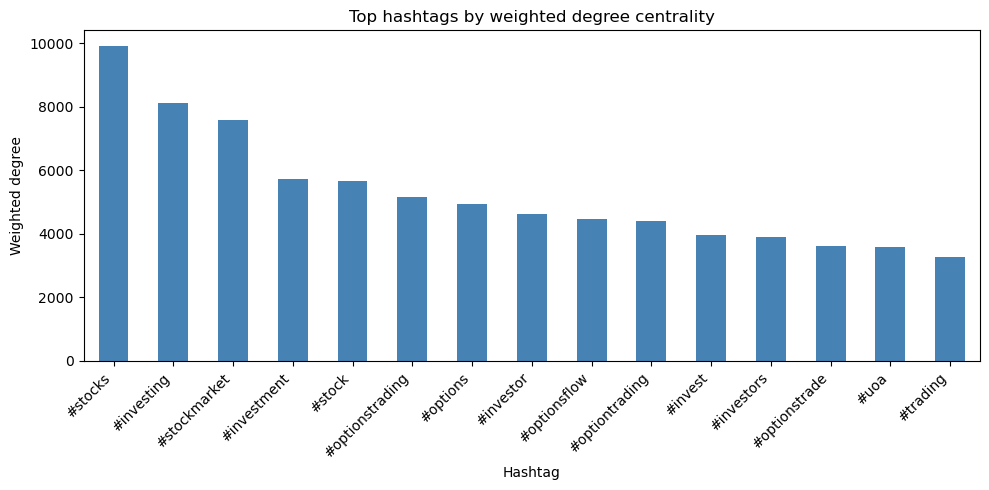

In [7]:
hashtag_centrality.to_csv("../outputs/tables/hashtag_centrality_top15.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
hashtag_centrality.set_index("node")["weighted_degree"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top hashtags by weighted degree centrality")
ax.set_xlabel("Hashtag")
ax.set_ylabel("Weighted degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/hashtag_centrality_bar.png", dpi=150)
plt.show()

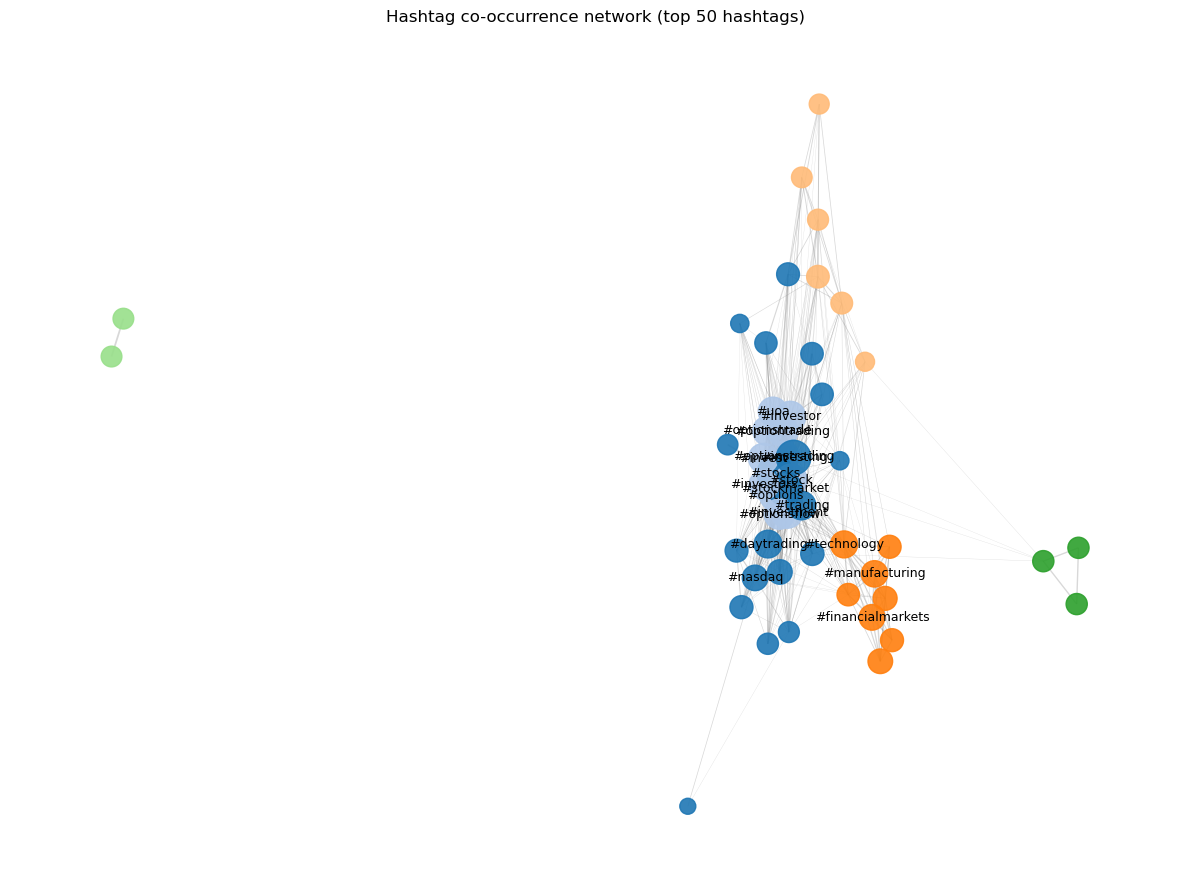

In [8]:
draw_network(
    hashtag_graph,
    title="Hashtag co-occurrence network (top 50 hashtags)",
    save_path="../outputs/figures/hashtag_network.png",
)

## 6. Mention Co-occurrence Network

**Nodes:** mentioned accounts (e.g., `@nvidia`, `@elonmusk`).
**Edges:** two accounts share an edge if they are mentioned together in the same tweet, weighted by the number of tweets that co-mention them.
**Why:** co-mention structure surfaces the *circles* of accounts that the crowd thinks about together when they tweet about NVIDIA — for example, financial-media accounts may cluster together while AI-industry accounts may cluster separately.

In [9]:
mention_graph = build_cooccurrence_graph(df["mentions"], top_n=40, min_pair_weight=2)
print(f"Mention network: {mention_graph.number_of_nodes()} nodes, {mention_graph.number_of_edges()} edges")

Mention network: 40 nodes, 46 edges


In [10]:
mention_centrality = top_centrality_table(mention_graph, top_k=15)
mention_centrality

,node,degree,weighted_degree,betweenness,eigenvector
0,@breakoutstocks,6,351,0.000000,NaN
1,@gambistefinance,6,351,0.000000,NaN
2,@unusual_whales,7,351,0.121457,NaN
3,@the_rocktrading,6,351,0.000000,NaN
4,@kongposting,6,351,0.000000,NaN
5,@bulitrades,6,349,0.000000,NaN
6,@tradewithalert,6,348,0.000000,NaN
7,@benderprofitbox,3,134,0.000000,NaN
8,@hellsbellsbbs,3,134,0.000000,NaN
9,@dasunman8,3,102,0.000000,NaN


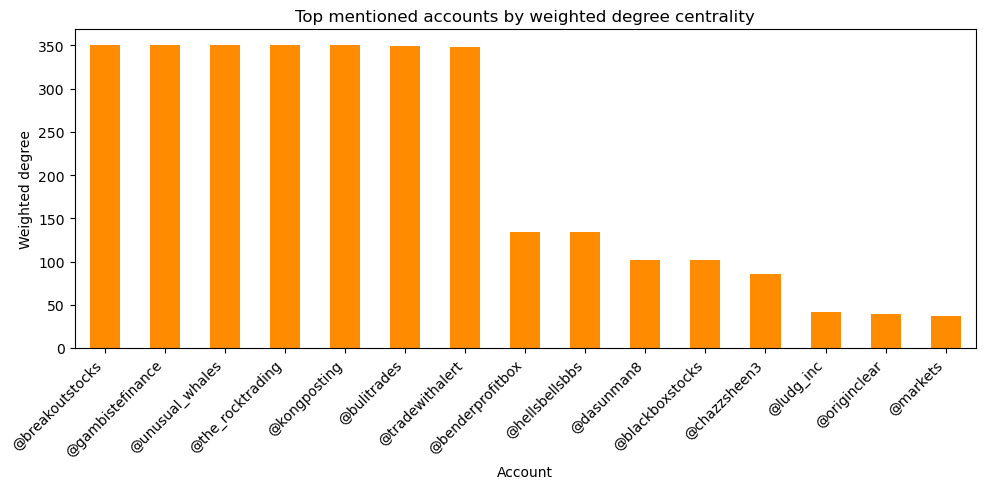

In [11]:
mention_centrality.to_csv("../outputs/tables/mention_centrality_top15.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
mention_centrality.set_index("node")["weighted_degree"].plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Top mentioned accounts by weighted degree centrality")
ax.set_xlabel("Account")
ax.set_ylabel("Weighted degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/mention_centrality_bar.png", dpi=150)
plt.show()

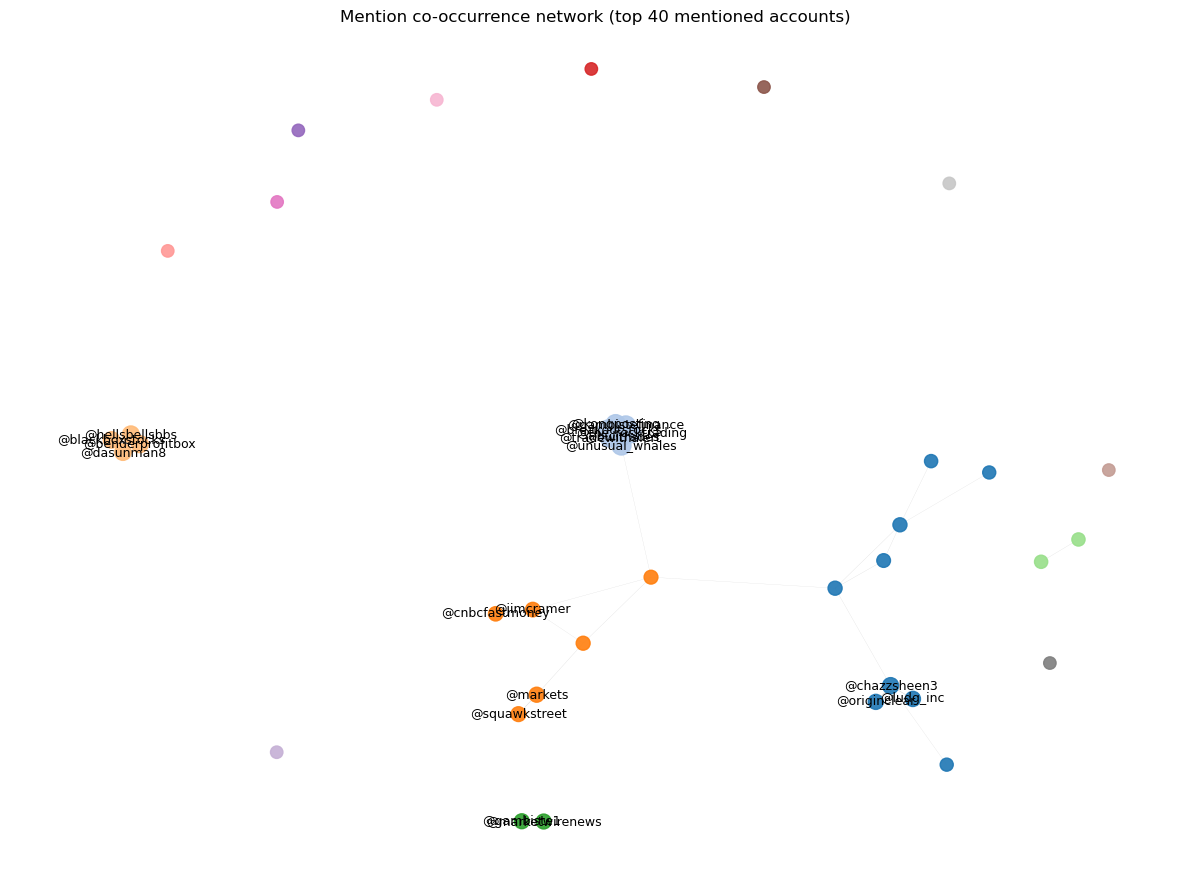

In [12]:
draw_network(
    mention_graph,
    title="Mention co-occurrence network (top 40 mentioned accounts)",
    save_path="../outputs/figures/mention_network.png",
)

## 7. Cashtag Co-occurrence Network

**Nodes:** stock cashtags such as `$NVDA`, `$TSLA`, `$AMD`.
**Edges:** two cashtags share an edge if they appear together in the same tweet, weighted by co-occurrence count.
**Why:** this is the most directly project-relevant network — it tells us which stocks the crowd talks about *alongside* NVDA, and reveals the trading clusters that NVDA belongs to (semiconductors, mega-cap tech, broad market ETFs, etc.).

In [13]:
cashtag_graph = build_cooccurrence_graph(df["cashtags"], top_n=50, min_pair_weight=5)
print(f"Cashtag network: {cashtag_graph.number_of_nodes()} nodes, {cashtag_graph.number_of_edges()} edges")

Cashtag network: 50 nodes, 1162 edges


In [14]:
cashtag_centrality = top_centrality_table(cashtag_graph, top_k=15)
cashtag_centrality

,node,degree,weighted_degree,betweenness,eigenvector
0,$NVDA,49,541867,0.0,0.381225
1,$TSLA,49,492036,0.0,0.353798
2,$SPY,49,434349,0.0,0.314936
3,$AAPL,49,427662,0.0,0.313856
4,$AMZN,49,393070,0.0,0.292357
5,$AMD,49,323091,0.0,0.239259
6,$QQQ,49,279903,0.0,0.210565
7,$BA,49,259244,0.0,0.191053
8,$BABA,49,258844,0.0,0.194537
9,$NFLX,49,258693,0.0,0.194535


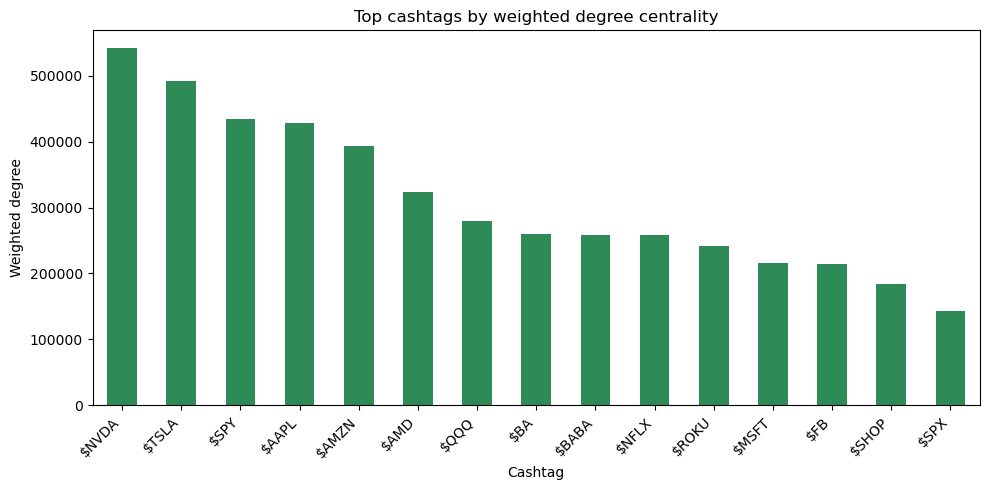

In [15]:
cashtag_centrality.to_csv("../outputs/tables/cashtag_centrality_top15.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
cashtag_centrality.set_index("node")["weighted_degree"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Top cashtags by weighted degree centrality")
ax.set_xlabel("Cashtag")
ax.set_ylabel("Weighted degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/cashtag_centrality_bar.png", dpi=150)
plt.show()

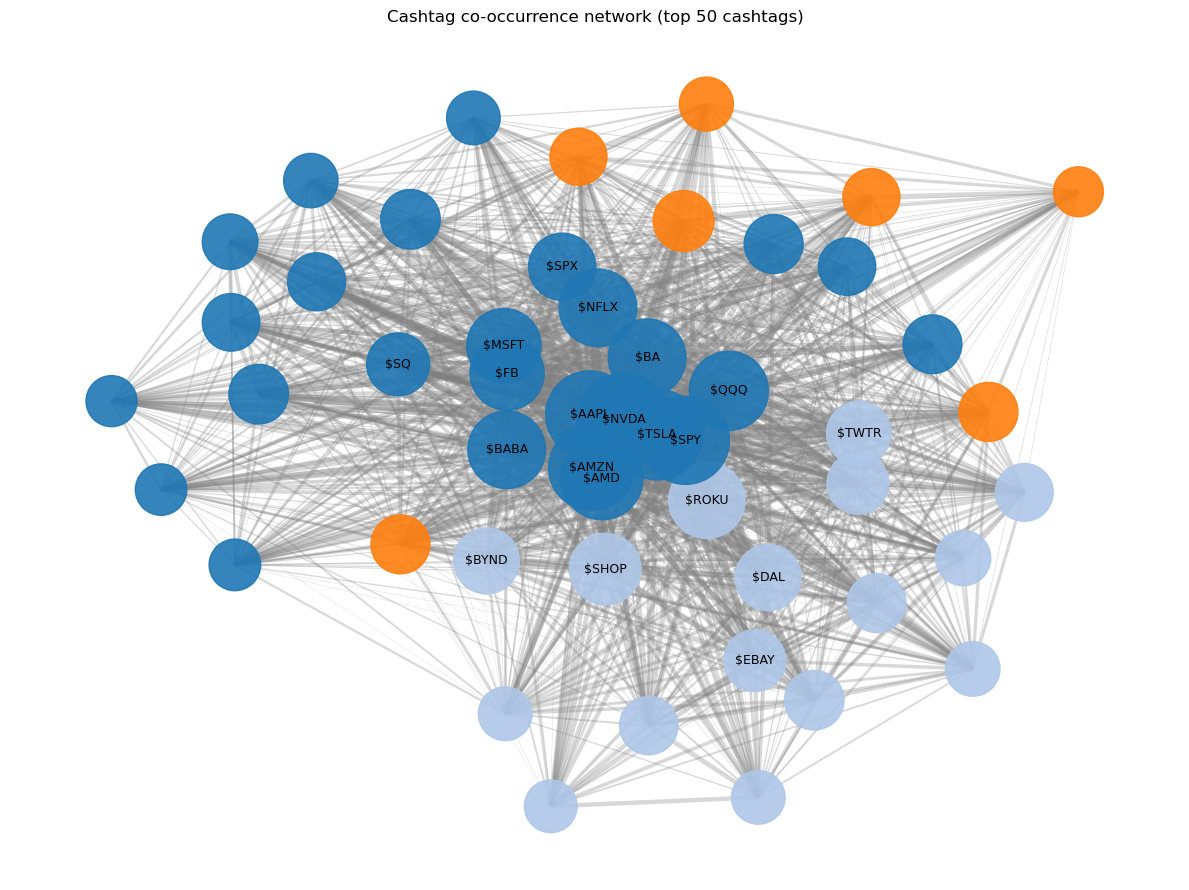

In [16]:
draw_network(
    cashtag_graph,
    title="Cashtag co-occurrence network (top 50 cashtags)",
    save_path="../outputs/figures/cashtag_network.png",
)

## 8. $NVDA Ego Network

To zoom in on NVIDIA specifically we extract the *ego network* of `$NVDA`: $NVDA plus all cashtags it directly co-occurs with in the cashtag graph. The edge widths give a quick view of which tickers are most strongly tied to NVDA in the conversation.

In [17]:
if "$NVDA" in cashtag_graph:
    ego = nx.ego_graph(cashtag_graph, "$NVDA")
    nvda_neighbors = sorted(
        ((n, cashtag_graph["$NVDA"][n]["weight"]) for n in cashtag_graph.neighbors("$NVDA")),
        key=lambda x: x[1],
        reverse=True,
    )
    nvda_neighbors_df = pd.DataFrame(nvda_neighbors, columns=["cashtag", "cooccurrence_with_NVDA"])
    nvda_neighbors_df.to_csv("../outputs/tables/nvda_cooccurring_cashtags.csv", index=False)
    print(f"$NVDA ego network: {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")
    display_df = nvda_neighbors_df.head(15)
else:
    ego = None
    display_df = pd.DataFrame()
display_df

$NVDA ego network: 50 nodes, 1162 edges


,cashtag,cooccurrence_with_NVDA
0,$TSLA,47163
1,$SPY,37905
2,$AAPL,37614
3,$AMZN,33758
4,$AMD,29061
5,$QQQ,22167
6,$NFLX,20330
7,$BABA,20238
8,$BA,19030
9,$MSFT,18303


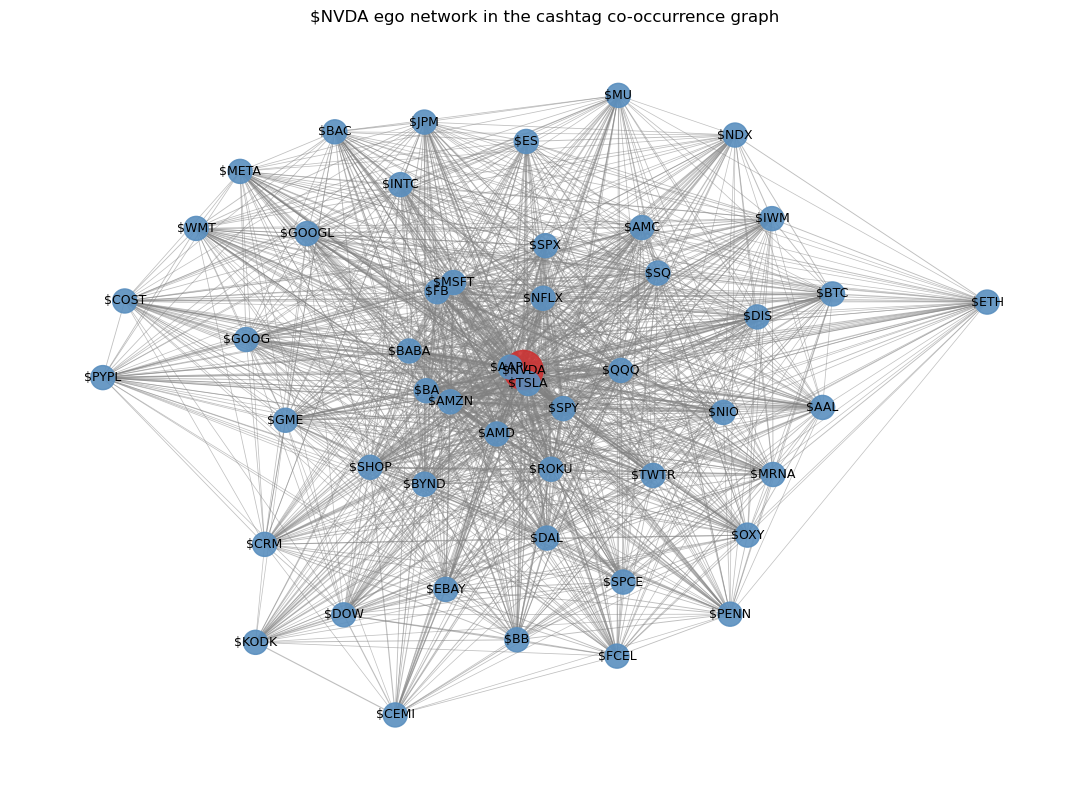

In [18]:
if ego is not None:
    pos = nx.spring_layout(ego, seed=7, k=0.8, iterations=80, weight="weight")
    plt.figure(figsize=(11, 8))
    weights = [ego[u][v]["weight"] for u, v in ego.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.5 + 4 * (w / max_w) for w in weights]
    node_sizes = [800 if n == "$NVDA" else 300 for n in ego.nodes()]
    node_colors = ["#cc3333" if n == "$NVDA" else "#5a8fbf" for n in ego.nodes()]
    nx.draw_networkx_edges(ego, pos, width=edge_widths, alpha=0.5, edge_color="grey")
    nx.draw_networkx_nodes(ego, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_labels(ego, pos, font_size=9)
    plt.title("$NVDA ego network in the cashtag co-occurrence graph")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("../outputs/figures/nvda_ego_network.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. User → Mentioned-Account Directed Network

The three co-occurrence graphs above describe *content* relationships. To go beyond that and look at *information flow* between users we build a directed network:

**Nodes:** Twitter accounts — both tweet authors (the `Username` column) and mentioned accounts (from the `mentions` column).
**Edges:** a directed edge `Username → @account` exists whenever a user mentions that account, weighted by the number of mentions.
**Directed?** Yes — mentioning is a one-way action.
**Weighted?** Yes — by mention count.

In this network, **in-degree centrality** corresponds to *being talked about* (influence / attention-receiving), and **out-degree centrality** corresponds to *talking about others* (engagement / amplification activity). This is the network analysis component that supports the COSC 2671 influence requirement.

In [19]:
# Build edge list: one row per mention from a tweet author
mention_edges = []
for _, row in df[["Username", "mentions"]].iterrows():
    user = row["Username"]
    if not isinstance(user, str):
        continue
    user = "@" + user.lower()
    for tgt in row["mentions"]:
        if tgt and tgt != user:
            mention_edges.append((user, tgt))

print("Total mention edges (raw):", len(mention_edges))

Total mention edges (raw): 10976


In [20]:
edge_weights = Counter(mention_edges)

DG = nx.DiGraph()
for (src, tgt), w in edge_weights.items():
    DG.add_edge(src, tgt, weight=w)

print(f"User-mention directed graph: {DG.number_of_nodes():,} nodes, {DG.number_of_edges():,} edges")

User-mention directed graph: 5,827 nodes, 7,391 edges


In [21]:
# Restrict to the largest weakly-connected component for analysis stability
if DG.number_of_nodes() > 0:
    largest_cc = max(nx.weakly_connected_components(DG), key=len)
    DG_main = DG.subgraph(largest_cc).copy()
    print(f"Largest weakly-connected component: {DG_main.number_of_nodes():,} nodes, {DG_main.number_of_edges():,} edges")
else:
    DG_main = DG

Largest weakly-connected component: 4,239 nodes, 6,352 edges


In [22]:
# Centrality measures for the directed network
in_deg = dict(DG_main.in_degree(weight="weight"))
out_deg = dict(DG_main.out_degree(weight="weight"))

try:
    pagerank = nx.pagerank(DG_main, weight="weight")
except Exception:
    pagerank = {n: np.nan for n in DG_main.nodes()}

user_mention_table = pd.DataFrame({
    "node": list(DG_main.nodes()),
    "in_degree_weighted": [in_deg[n] for n in DG_main.nodes()],
    "out_degree_weighted": [out_deg[n] for n in DG_main.nodes()],
    "pagerank": [pagerank[n] for n in DG_main.nodes()],
})

top_influencers = user_mention_table.sort_values("in_degree_weighted", ascending=False).head(15).reset_index(drop=True)
top_amplifiers = user_mention_table.sort_values("out_degree_weighted", ascending=False).head(15).reset_index(drop=True)
top_pagerank = user_mention_table.sort_values("pagerank", ascending=False).head(15).reset_index(drop=True)

top_influencers.to_csv("../outputs/tables/user_mention_top_influencers.csv", index=False)
top_amplifiers.to_csv("../outputs/tables/user_mention_top_amplifiers.csv", index=False)
top_pagerank.to_csv("../outputs/tables/user_mention_top_pagerank.csv", index=False)

print("Top 5 accounts by weighted in-degree (most mentioned):")
print(top_influencers.head(5).to_string(index=False))

Top 5 accounts by weighted in-degree (most mentioned):
           node  in_degree_weighted  out_degree_weighted  pagerank
@marketwirenews                 529                    0  0.016273
     @ajtrader7                 192                    0  0.005214
       @youtube                 138                    0  0.005929
@unusual_whales                 136                    0  0.005832
   @chazzsheen3                 132                    0  0.001386


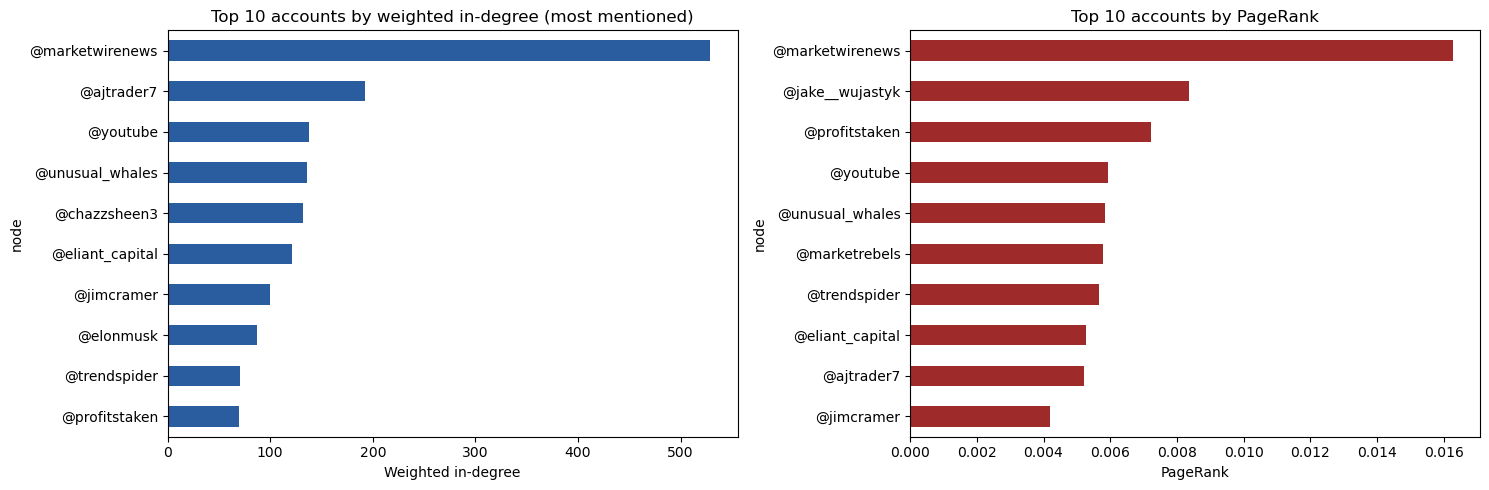

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_influencers.head(10).set_index("node")["in_degree_weighted"].plot(
    kind="barh", ax=axes[0], color="#2a5d9f"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 10 accounts by weighted in-degree (most mentioned)")
axes[0].set_xlabel("Weighted in-degree")

top_pagerank.head(10).set_index("node")["pagerank"].plot(
    kind="barh", ax=axes[1], color="#9f2a2a"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 10 accounts by PageRank")
axes[1].set_xlabel("PageRank")

plt.tight_layout()
plt.savefig("../outputs/figures/user_mention_influence_bars.png", dpi=150)
plt.show()

Sub-network for visualisation: 124 nodes, 146 edges


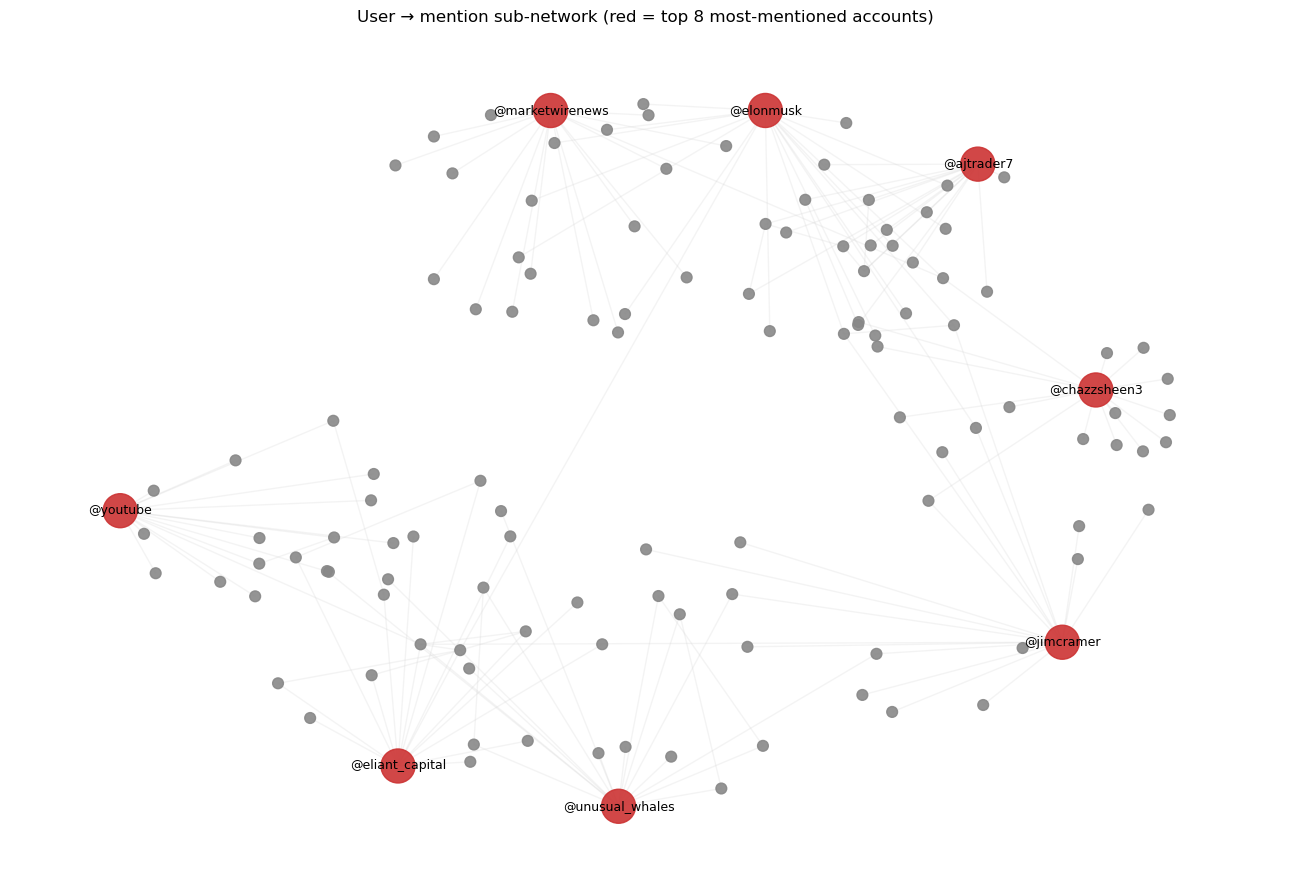

In [24]:
# Visualise the network around the most-mentioned accounts only, to keep it readable.
top_targets = top_influencers["node"].tolist()[:8]
sub_nodes = set(top_targets)
for tgt in top_targets:
    # add the most active in-neighbours of each top target
    preds = sorted(DG_main.predecessors(tgt),
                   key=lambda u: DG_main[u][tgt]["weight"],
                   reverse=True)[:15]
    sub_nodes.update(preds)
sub = DG_main.subgraph(sub_nodes).copy()
print(f"Sub-network for visualisation: {sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges")

pos = nx.spring_layout(sub, seed=11, k=0.7, iterations=80, weight="weight")
plt.figure(figsize=(13, 9))
node_colors = ["#cc3333" if n in top_targets else "#888888" for n in sub.nodes()]
node_sizes = [600 if n in top_targets else 60 for n in sub.nodes()]
nx.draw_networkx_edges(sub, pos, alpha=0.25, arrows=False, edge_color="lightgrey")
nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
labels = {n: n for n in top_targets}
nx.draw_networkx_labels(sub, pos, labels=labels, font_size=9)
plt.title("User → mention sub-network (red = top 8 most-mentioned accounts)")
plt.axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/user_mention_subnetwork.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Stock Price Comparison

We now compare the daily sentiment signal against NVIDIA's actual stock price over the same period. We:
1. Load the daily sentiment summary `nvidia_daily_sentiment.csv`.
2. Download NVDA's daily OHLCV data with `yfinance` for the same date range.
3. Merge on `date` and compute daily returns.
4. Plot price next to sentiment / tweet volume.
5. Compute Pearson and Spearman correlations between sentiment, tweet volume, and returns.
6. Run a *lag analysis* to see whether sentiment leads, lags, or moves with returns.

In [25]:
daily = pd.read_csv("../data/processed/nvidia_daily_sentiment.csv")
daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values("date").reset_index(drop=True)
print("Daily sentiment shape:", daily.shape)
daily.head()

Daily sentiment shape: (78, 6)


,date,tweet_count,average_sentiment,positive_count,neutral_count,negative_count
0,2022-11-21,661,0.212901,335,227,99
1,2022-11-22,1411,0.214759,751,514,146
2,2022-11-23,1189,0.235317,622,460,107
3,2022-11-24,876,0.252928,516,266,94
4,2022-11-25,781,0.235235,441,256,84


In [ ]:
start_date = daily["date"].min() - pd.Timedelta(days=2)
end_date = daily["date"].max() + pd.Timedelta(days=2)
print("Fetching NVDA prices from", start_date.date(), "to", end_date.date())

nvda = yf.download(
    "NVDA",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    progress=False,
    auto_adjust=True,
)

# Flatten yfinance multi-level columns if present
if isinstance(nvda.columns, pd.MultiIndex):
    nvda.columns = [c[0] for c in nvda.columns]

# Read date off the DataFrame index (column name varies across yfinance versions)
nvda["date"] = pd.to_datetime(nvda.index).normalize()
nvda = nvda.reset_index(drop=True)

nvda["daily_return"] = nvda["Close"].pct_change()
nvda["log_return"] = np.log(nvda["Close"] / nvda["Close"].shift(1))
print("NVDA price shape:", nvda.shape)
nvda.head()

In [ ]:
# Merge the daily sentiment with stock price on trading days only
combined = pd.merge(
    daily, nvda[["date", "Close", "Volume", "daily_return", "log_return"]],
    on="date", how="inner"
).sort_values("date").reset_index(drop=True)
print("Combined (trading-day) shape:", combined.shape)
combined.to_csv("../outputs/tables/sentiment_vs_stock_daily.csv", index=False)
combined.head()

In [ ]:
# Plot 1 — Close price overlaid with average daily sentiment
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(combined["date"], combined["Close"], color="#2a5d9f", label="NVDA close price")
ax1.set_ylabel("NVDA close price (USD)", color="#2a5d9f")
ax1.tick_params(axis="y", labelcolor="#2a5d9f")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(combined["date"], combined["average_sentiment"], color="#cc7a00", label="Avg daily sentiment")
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.7)
ax2.set_ylabel("Average daily sentiment (VADER compound)", color="#cc7a00")
ax2.tick_params(axis="y", labelcolor="#cc7a00")

plt.title("NVDA close price vs. average daily tweet sentiment")
fig.tight_layout()
plt.savefig("../outputs/figures/stock_vs_sentiment.png", dpi=150)
plt.show()

In [ ]:
# Plot 2 — Tweet volume vs. trading volume
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(combined["date"], combined["tweet_count"], color="#7aa8d8", alpha=0.7, label="Tweet count")
ax1.set_ylabel("Daily tweet count", color="#2a5d9f")
ax1.tick_params(axis="y", labelcolor="#2a5d9f")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(combined["date"], combined["Volume"], color="#cc3333", label="NVDA volume")
ax2.set_ylabel("NVDA trading volume", color="#cc3333")
ax2.tick_params(axis="y", labelcolor="#cc3333")

plt.title("Daily NVIDIA tweet volume vs. NVDA trading volume")
fig.tight_layout()
plt.savefig("../outputs/figures/tweet_volume_vs_trading_volume.png", dpi=150)
plt.show()

In [ ]:
# Correlations between sentiment / tweet volume and stock metrics.
# We use pandas' .corr() (numpy-based) so no extra dependency is needed; if
# scipy is installed we also report the p-values, otherwise we leave them blank.
try:
    from scipy.stats import pearsonr, spearmanr
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False
    print("scipy not available — correlation p-values will be skipped.")

def corr_table(frame, x_cols, y_cols):
    rows = []
    for x in x_cols:
        for y in y_cols:
            sub = frame[[x, y]].dropna()
            n = len(sub)
            if n < 5:
                rows.append({"x": x, "y": y, "n": n, "pearson_r": np.nan,
                             "pearson_p": np.nan, "spearman_r": np.nan, "spearman_p": np.nan})
                continue
            pr = sub[x].corr(sub[y], method="pearson")
            sr = sub[x].corr(sub[y], method="spearman")
            if _HAS_SCIPY:
                _, pp = pearsonr(sub[x], sub[y])
                _, sp = spearmanr(sub[x], sub[y])
            else:
                pp, sp = np.nan, np.nan
            rows.append({"x": x, "y": y, "n": n, "pearson_r": pr,
                         "pearson_p": pp, "spearman_r": sr, "spearman_p": sp})
    return pd.DataFrame(rows)

correlation_table = corr_table(
    combined,
    x_cols=["average_sentiment", "tweet_count", "positive_count", "negative_count"],
    y_cols=["Close", "daily_return", "log_return", "Volume"],
)
correlation_table.to_csv("../outputs/tables/sentiment_stock_correlations.csv", index=False)
correlation_table

In [ ]:
# Scatter — average sentiment vs. daily return
plot_df = combined.dropna(subset=["average_sentiment", "daily_return"])
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["average_sentiment"], plot_df["daily_return"], alpha=0.7, color="#2a5d9f")
if len(plot_df) >= 2:
    z = np.polyfit(plot_df["average_sentiment"], plot_df["daily_return"], 1)
    xs = np.linspace(plot_df["average_sentiment"].min(), plot_df["average_sentiment"].max(), 100)
    ax.plot(xs, np.polyval(z, xs), color="#cc3333", linewidth=2,
            label=f"linear fit: y={z[0]:.4f}x+{z[1]:.4f}")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.7)
ax.axvline(0, color="grey", linestyle="--", linewidth=0.7)
ax.set_xlabel("Average daily sentiment (VADER compound)")
ax.set_ylabel("NVDA daily return")
ax.set_title("Same-day sentiment vs. NVDA daily return")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_vs_return_scatter.png", dpi=150)
plt.show()

In [ ]:
# Lag analysis — does sentiment lead, lag, or move with returns?
lag_rows = []
for lag in range(-5, 6):  # negative lag = sentiment leads stock
    if lag < 0:
        x = combined["average_sentiment"].shift(-lag)  # shift sentiment forward
        y = combined["daily_return"]
        desc = f"sentiment leads stock by {abs(lag)}d"
    elif lag > 0:
        x = combined["average_sentiment"]
        y = combined["daily_return"].shift(lag)         # stock follows by `lag` days
        desc = f"stock leads sentiment by {lag}d"
    else:
        x = combined["average_sentiment"]
        y = combined["daily_return"]
        desc = "same day"
    sub = pd.concat([x, y], axis=1).dropna()
    sub.columns = ["x", "y"]
    if len(sub) >= 5:
        r = sub["x"].corr(sub["y"], method="pearson")
        if _HAS_SCIPY:
            _, p = pearsonr(sub["x"], sub["y"])
        else:
            p = np.nan
    else:
        r, p = np.nan, np.nan
    lag_rows.append({"lag": lag, "description": desc, "pearson_r": r, "p_value": p, "n": len(sub)})

lag_df = pd.DataFrame(lag_rows)
lag_df.to_csv("../outputs/tables/sentiment_return_lag_correlations.csv", index=False)
lag_df

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lag_df["lag"], lag_df["pearson_r"],
       color=["#cc3333" if r < 0 else "#2a5d9f" for r in lag_df["pearson_r"].fillna(0)])
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_xticks(lag_df["lag"])
ax.set_xlabel("Lag (negative = sentiment leads stock)")
ax.set_ylabel("Pearson correlation with daily return")
ax.set_title("Lagged correlation: avg daily sentiment vs. NVDA daily return")
plt.tight_layout()
plt.savefig("../outputs/figures/sentiment_return_lag.png", dpi=150)
plt.show()

## 11. Summary

This notebook produced the network and stock-comparison portion of the project:

1. **Hashtag, mention, and cashtag co-occurrence networks** — each undirected and weighted by the number of tweets in which the tag pair appears together. We computed degree, weighted degree, betweenness, and eigenvector centrality, detected communities with greedy modularity, and saved both the centrality tables and the network plots.
2. **$NVDA ego network** — extracted from the cashtag graph to surface the tickers the crowd talks about alongside NVDA.
3. **User → mention directed network** — a directed weighted graph between tweet authors and the accounts they mention. Weighted in-degree and PageRank identify the most-mentioned (influential) accounts; out-degree identifies the most active amplifiers. This is the influence component that supports the project's interpretation of user roles.
4. **Stock price comparison** — daily sentiment from Notebook 2 was joined with NVDA closing prices and trading volume, then visualised as overlays and a scatter, and tested with Pearson and Spearman correlations plus a ±5-day lag analysis.

All tables are written to `../outputs/tables/` and all figures to `../outputs/figures/` so they can be referenced from the report.